<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/MainQuest/Quest04/GenAI_proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

last modified date : 2026.03  
제작 : 박광석 (모두의연구소)

# 들어가며  

우리가 오늘 다룰 Score-based SDE는 수만 번의 미분 계산과 병렬 처리가 필수적입니다. 이 복잡한 수학적 경로를 가장 우아하고 빠르게 처리하기 위해, 우리는 구글의 차세대 엔진, JAX/Flax 를 사용합니다.  

**JAX (Just-After-eXecution): "수학을 코드로 바꾸는 가장 빠른 방법"**   
  
JAX는 구글 DeepMind에서 개발한 고성능 수치 계산 라이브러리로, 복잡한 미분 방정식과 대규모 행렬 연산을 다루는 생성 모델 연구의 패러다임을 바꾼 도구입니다. 단순히 계산을 돕는 API를 넘어, 우리가 작성한 Python/NumPy 코드를 가속기(GPU/TPU)가 가장 선호하는 형태인 고도로 최적화된 기계어로 실시간 변환해주는 고성능 수치 컴퓨팅 플랫폼이라 정의할 수 있습니다.  

- XLA 기반의 압도적 속도: JAX는 XLA(Accelerated Linear Algebra)를 통해 파이썬 코드를 기계어 수준으로 최적화합니다. 일반적인 파이썬 루프 대비 최대 10~100배 이상의 실행 속도 향상을 보여주며, 특히 행렬 연산이 많은 생성 모델에서 그 차이가 극명합니다.  
- 고차 미분(Autodiff)의 끝판왕: Score-matching은 로그 확률 밀도의 기울기(Gradient)를 구하는 것이 핵심입니다. JAX는 grad(grad(f))처럼 미분의 미분을 구하는 고차 미분을 기본적으로 지원하며, 이는 PyTorch보다 훨씬 직관적이고 메모리 효율적입니다.  
- Vectorization (vmap): 수천 개의 데이터를 한꺼번에 처리할 때, 복잡한 for문 없이도 vmap 함수 하나로 자동으로 병렬화합니다. 이는 코딩 실수를 줄여줄 뿐만 아니라, 하드웨어 활용도를 극대화합니다.

**Flax: "대규모 생성 모델을 위한 정교한 설계도"**  
JAX가 강력한 '엔진'이라면, Flax는 그 엔진을 얹은 '고성능 스포츠카의 차체'입니다.

- 함수형 프로그래밍과 상태 분리: Flax는 모델의 **구조(변수 간의 관계)** 와 **상태(실제 파라미터 값)** 를 엄격히 분리합니다. 덕분에 학습 중에 모델의 가중치만 쏙 뽑아내어 저장하거나(Checkpointing), 다른 장치로 전송하는 과정이 매우 가볍고 빠릅니다.

- pmap을 통한 무한한 확장성: JAX의 pmap과 결합하면 단 한 줄의 코드로 여러 장의 GPU/TPU에 데이터를 분산시킬 수 있습니다. 이를 통해 단일 GPU 대비 장치 개수에 비례하는 **선형적인 학습 속도 향상(Linear Scaling)** 을 경험할 수 있습니다.

- 결정론적 관리: 생성 모델에서 중요한 난수 생성(Random seed)을 매우 엄격하게 관리합니다. 덕분에 수천 번의 샘플링 과정에서도 동일한 조건이라면 100% 동일한 결과(Reproducibility)를 보장하며, 이는 연구 정밀도를 비약적으로 높여줍니다.

## JAX의 핵심 철학  


**순수 함수 (Pure Functions)**  
JAX는 가속화된 연산을 위해 함수를 추적하고 컴파일합니다. 이 과정이 제대로 작동하려면 함수가 순수 함수여야 합니다.

순수 함수의 조건은 다음과 같습니다.  
- 결정론적: 동일한 입력에 대해 항상 동일한 출력을 반환합니다.
- 부작용(Side Effect) 없음: 함수 외부의 상태를 수정하거나, 전역 변수를 변경하거나, 입력을 직접 수정하지 않습니다.

```
# 잘못된 예시
import jax.numpy as jnp

g_var = 5  # 전역 변수

def impure_func(x):
    return x + g_var  # 외부 상태에 의존 (순수하지 않음)

```





```
#바른 예시
def pure_func(x, state):
    return x + state  # 모든 필요한 정보를 인자로 전달
```



**상태 관리 (State Management)**  
PyTorch나 TensorFlow는 모델의 가중치를 객체의 **내부 상태(Internal State)** 로 저장하고 업데이트합니다.   
반면, JAX는 상태를 함수 외부에 두고, 매 단계마다 명시적으로 주고받습니다.  

**함수형 업데이트와 불변성 (Immutability)**  
JAX의 배열(DeviceArray)은 **불변(Immutable)**입니다. 즉, 생성된 배열의 값을 직접 바꿀 수 없습니다. 값을 변경하고 싶다면, 변경된 "새로운 배열"을 생성해야 합니다.



```
import jax
import jax.numpy as jnp

x = jnp.array([1, 2, 3])

# x[0] = 10  <-- TypeError 발생!

# 새로운 배열을 반환하는 방식
new_x = x.at[0].set(10)

print(x)      # [1, 2, 3] (원본 유지)
print(new_x)  # [10, 2, 3] (새로운 객체)
```



이 방식은 비효율적으로 보일 수 있지만, JAX의 XLA 컴파일러가 실제 메모리 연산 시에는 이를 최적화하여 불필요한 복사를 방지합니다.

요약하자면, 이 예제의 코드는 다음을 유념하여 구현되었습니다.  
- 상태는 밖으로: 모델의 가중치는 함수 안에 숨기지 말고 밖에서 관리합니다.  
- 복사본 생성: 값을 바꾸는 대신, 바뀐 값을 가진 새 버전을 만듭니다.  
- 명시적 흐름: (input, state) -> (output, new_state) 구조를 유지합니다.  

코드 중간중간 상태를 복사하는 부분을 유념하여 살펴보시기 바랍니다!

# ScoreNet 아키텍처

ScoreNet은 연속적인 시간축 $t \in [0, 1]$에 대해 정의된 스코어 함수 $\nabla_{x} \log p_{t}(x)$를 근사하기 위한 신경망입니다. 이 모델은 입력 데이터의 공간적 정보와 시간 정보를 결합하여 처리하도록 설계되었습니다.

In [ ]:
!pip install optax

In [ ]:
import jax.numpy as jnp
import numpy as np
import flax
import flax.linen as nn
from typing import Any, Tuple
import functools
import jax
import optax
from torchvision.utils import make_grid




먼저, 시간 정보의 인코딩를 위해 GaussianFourierProjection 를 정의하겠습니다.   
시간 변수 $t$는 단순한 스칼라 값이지만, 신경망이 이를 고차원 특징 공간에서 인식할 수 있도록 변환이 필요합니다.
- 역할: 입력된 시간 $t$를 가우시안 랜덤 피처(Gaussian Random Features)를 이용해 임베딩 벡터로 사영합니다.
- 고정된 파라미터: 클래스 내부의 $W$는 jax.nn.initializers.normal로 초기화되지만, jax.lax.stop_gradient(W)를 통해 학습 대상에서 제외됩니다. 이는 시간 축에 대한 기준 좌표계를 고정하는 효과를 줍니다.
- 출력: $\sin(2\pi \cdot x \cdot W)$와 $\cos(2\pi \cdot x \cdot W)$를 결합하여 주기적 성질을 가진 벡터를 생성합니다.

In [ ]:

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""
  embed_dim: int
  scale: float = 30.
  @nn.compact
  def __call__(self, x):
    # Randomly sample weights during initialization. These weights are fixed
    # during optimization and are not trainable.
    W = self.param('W', jax.nn.initializers.normal(stddev=self.scale),
                 (self.embed_dim // 2, ))
    W = jax.lax.stop_gradient(W)
    x_proj = x[:, None] * W[None, :] * 2 * jnp.pi
    return jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)




이어 특징 맵 결합을 위해 차원을 변환해주는 Dense 레이어를 정의합니다.  
시간 임베딩 벡터를 이미지 형태의 텐서와 연산할 수 있도록 물리적 형상을 맞추는 역할을 합니다.

In [ ]:
class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  output_dim: int

  @nn.compact
  def __call__(self, x):
    return nn.Dense(self.output_dim)(x)[:, None, None, :]



U-Net 기반으로 메인 네트워크, ScoreNet을 정의합니다.  
다양한 해상도에서 특징을 추출하고 복원하는 U-Net 구조를 통해 최종적인 스코어 필드(Score Field)를 출력합니다.  
- Encoding Path (수축 경로):nn.Conv와 nn.GroupNorm을 사용하여 특징을 추출하며 해상도를 줄여나갑니다. 각 층마다 Dense(embed)를 통해 시간 정보를 반복적으로 주입하여 모델이 현재 노이즈 레벨에 종속적인 스코어를 계산하게 합니다.
- Decoding Path (확장 경로):nn.Conv와 jnp.concatenate를 이용해 하위 층의 특징과 수축 경로에서의 스킵 연결(Skip Connection)을 합칩니다. Dilated Convolution: 입력 확장(Input Dilation)을 사용하여 파라미터 수 증가 없이 수용 영역(Receptive Field)을 넓혀 전역적인 데이터 분포를 파악합니다.
- Output Normalization:최종 출력 단계에서 marginal_prob_std(t)로 나누어줍니다.이는 각 시간대별로 상이한 스코어의 크기(Magnitude)를 정규화하여 학습 안정성을 높이는 기법입니다.

In [ ]:

class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture.

  Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
  """
  marginal_prob_std: Any
  channels: Tuple[int] = (32, 64, 128, 256)
  embed_dim: int = 256

  @nn.compact
  def __call__(self, x, t):
    # The swish activation function
    act = nn.swish
    # Obtain the Gaussian random feature embedding for t
    embed = act(nn.Dense(self.embed_dim)(
        GaussianFourierProjection(embed_dim=self.embed_dim)(t)))

    # Encoding path
    h1 = nn.Conv(self.channels[0], (3, 3), (1, 1), padding='VALID',
                   use_bias=False)(x)
    ## Incorporate information from t
    h1 += Dense(self.channels[0])(embed)
    ## Group normalization
    h1 = nn.GroupNorm(4)(h1)
    h1 = act(h1)
    h2 = nn.Conv(self.channels[1], (3, 3), (2, 2), padding='VALID',
                   use_bias=False)(h1)
    h2 += Dense(self.channels[1])(embed)
    h2 = nn.GroupNorm()(h2)
    h2 = act(h2)
    h3 = nn.Conv(self.channels[2], (3, 3), (2, 2), padding='VALID',
                   use_bias=False)(h2)
    h3 += Dense(self.channels[2])(embed)
    h3 = nn.GroupNorm()(h3)
    h3 = act(h3)
    h4 = nn.Conv(self.channels[3], (3, 3), (2, 2), padding='VALID',
                   use_bias=False)(h3)
    h4 += Dense(self.channels[3])(embed)
    h4 = nn.GroupNorm()(h4)
    h4 = act(h4)

    # Decoding path
    h = nn.Conv(self.channels[2], (3, 3), (1, 1), padding=((2, 2), (2, 2)),
                  input_dilation=(2, 2), use_bias=False)(h4)
    ## Skip connection from the encoding path
    h += Dense(self.channels[2])(embed)
    h = nn.GroupNorm()(h)
    h = act(h)
    h = nn.Conv(self.channels[1], (3, 3), (1, 1), padding=((2, 3), (2, 3)),
                  input_dilation=(2, 2), use_bias=False)(
                      jnp.concatenate([h, h3], axis=-1)
                  )
    h += Dense(self.channels[1])(embed)
    h = nn.GroupNorm()(h)
    h = act(h)
    h = nn.Conv(self.channels[0], (3, 3), (1, 1), padding=((2, 3), (2, 3)),
                  input_dilation=(2, 2), use_bias=False)(
                      jnp.concatenate([h, h2], axis=-1)
                  )
    h += Dense(self.channels[0])(embed)
    h = nn.GroupNorm()(h)
    h = act(h)
    h = nn.Conv(1, (3, 3), (1, 1), padding=((2, 2), (2, 2)))(
        jnp.concatenate([h, h1], axis=-1)
    )

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

## Denoising Score Matching Objective 목적 함수 설정 및 훈련


## Training with Weighted Sum of Denoising Score Matching Objectives

Now let's get our hands dirty on training. First of all, we need to specify an SDE that perturbs the data distribution $p_0$ to a prior distribution $p_T$. We choose the following SDE
\begin{align*}
d \mathbf{x} = \sigma^t d\mathbf{w}, \quad t\in[0,1]
\end{align*}
In this case,
\begin{align*}
p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0)) = \mathcal{N}\bigg(\mathbf{x}(t); \mathbf{x}(0), \frac{1}{2\log \sigma}(\sigma^{2t} - 1) \mathbf{I}\bigg)
\end{align*}
and we can choose the weighting function $\lambda(t) = \frac{1}{2 \log \sigma}(\sigma^{2t} - 1)$.

When $\sigma$ is large, the prior distribution, $p_{t=1}$ is
\begin{align*}
\int p_0(\mathbf{y})\mathcal{N}\bigg(\mathbf{x}; \mathbf{y}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg) d \mathbf{y} \approx \mathbf{N}\bigg(\mathbf{x}; \mathbf{0}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg),
\end{align*}
which is approximately independent of the data distribution and is easy to sample from.

Intuitively, this SDE captures a continuum of Gaussian perturbations with variance function $\frac{1}{2 \log \sigma}(\sigma^{2t} - 1)$. This continuum of perturbations allows us to gradually transfer samples from a data distribution $p_0$ to a simple Gaussian distribution $p_1$.

### SDE 계수 및 가중치 함수 정의하기  
데이터 분포를 점진적으로 가우시안 분포로 전이시키기 위한 핵심 함수들을 구현합니다.

앞서 수학식으로 살펴본 퍼터베이션 커널, $p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0))$ 분포의 표준편차를 계산합니다.
- 역할: 깨끗한 이미지에 $t$만큼 시간이 흘렀을 때 주입되어야 할 노이즈의 강도(표준편차)를 반환합니다.
- 구현: $t=0$일 때 결과값이 0이 되어 노이즈가 없음을 보장하며, $t$가 커질수록 $\sigma^{t}$에 비례하여 노이즈가 급격히 증가합니다.
- 용도: 학습 시 데이터를 오염시키거나, 모델의 출력을 정규화할 때 사용됩니다.  

In [ ]:

def marginal_prob_std(t, sigma):
  """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.

  Args:
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.

  Returns:
    The standard deviation.
  """
  return jnp.sqrt((sigma**(2 * t) - 1.) / 2. / jnp.log(sigma))



<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_920/2916880952.py:8: SyntaxWarning: invalid escape sequence '\s'
  sigma: The $\sigma$ in our SDE.
/tmp/ipykernel_920/2916880952.py:20: SyntaxWarning: invalid escape sequence '\s'
  sigma: The $\sigma$ in our SDE.


확산 계수 계산 함수를 정의합니다.  
SDE 공식 $dx = g(t)dw$에서 무작위 노이즈의 순성 변화량을 결정하는 $g(t)$를 계산합니다.  
- 역할: 매 찰나(dt)마다 주입되는 노이즈의 세기를 결정합니다.
- 구현: 선택한 SDE 정의에 따라 $g(t) = \sigma^t$로 계산됩니다.
- 용도: 주로 샘플링(Inference) 단계에서 역방향 SDE를 풀 때, 노이즈를 걷어내는 보폭을 조절하는 데 쓰입니다.

In [ ]:
def diffusion_coeff(t, sigma):
  """Compute the diffusion coefficient of our SDE.

  Args:
    t: A vector of time steps.
    sigma: The $\sigma$ in our SDE.

  Returns:
    The vector of diffusion coefficients.
  """
  return sigma**t

sigma =  25.0#@param {'type':'number'}
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

functools.partial 은 JAX 환경에서 하이퍼파라미터 $\sigma$를 효율적으로 관리하기 위한 기법입니다. $\sigma$ 값을 상수로 설정한 뒤, partial을 통해 $\sigma$가 입력된 상태의 새로운 함수(_fn)를 만드는 방식입니다. 이후 코드에서 매번 $\sigma$를 인자로 넘길 필요 없이 시간 $t$만 입력하면 즉시 계수를 얻을 수 있어 코드가 간결해지고 실수를 줄여줍니다.
여기서는 25.0로 설정했습니다.

### 손실 함수와 학습 최적화 알고리즘  
모델이 데이터의 분포(Score Field)를 정확히 학습하도록 유도하는 수치적 방법론을 구현합니다.

모델 $s_{\theta}(x, t)$가 실제 데이터의 스코어 $\nabla_{x} \log p_{t}(x)$를 얼마나 잘 모사하는지 평가합니다.
- 시간 및 노이즈 샘플링
    - jax.random.uniform: eps부터 1 사이의 연속적인 시간 $t$를 배치 크기만큼 무작위로 추출합니다. 이는 모델이 모든 노이즈 레벨에 대해 대응할 수 있도록 합니다.
    - jax.random.normal: 표준 정규 분포로부터 노이즈 $z$를 생성합니다.

- 데이터 오염(Perturbation):
    - 원본 데이터 $x$에 $z \cdot \sigma_t$를 더해 $x_t$를 생성합니다. 이때 std는 앞서 정의한 퍼터베이션 커널의 표준편차입니다.
    
    
- 스코어 예측 및 오차 계산:
    - model.apply: 오염된 데이터 $perturbed\_x$와 시간 $random\_t$를 입력하여 스코어를 예측합니다.
    - Loss 계산: 예측된 스코어와 실제 정답 방향(노이즈의 역방향) 사이의 MSE(Mean Squared Error)를 계산합니다. 수식적으로 이는 Fisher Divergence를 최소화하는 것과 동일합니다.

In [ ]:


def loss_fn(rng, model, params, x, marginal_prob_std, eps=1e-5):
  """The loss function for training score-based generative models.

  Args:
    model: A `flax.linen.Module` object that represents the structure of
      the score-based model.
    params: A dictionary that contains all trainable parameters.
    x: A mini-batch of training data.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
  """
  rng, step_rng = jax.random.split(rng)
  random_t = jax.random.uniform(step_rng, (x.shape[0],), minval=eps, maxval=1.)
  rng, step_rng = jax.random.split(rng)
  z = jax.random.normal(step_rng, x.shape)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model.apply(params, perturbed_x, random_t)
  loss = jnp.mean(jnp.sum((score * std[:, None, None, None] + z)**2,
                          axis=(1,2,3)))
  return loss



학습 스텝 정의 시 에서는 학습 속도를 극대화하기 위해 JAX의 하드웨어 가속 기능을 활용합니다. 여기에서 JAX를 이용한 병렬 최적화를 적용합니다.

jax.value_and_grad:
손실 함수의 결과값(value)과 파라미터에 대한 기울기(grad)를 동시에 계산하는 JAX의 고유 함수입니다. argnums=2는 세 번째 인자인 params에 대해 미분을 수행하겠다는 의미입니다.
jax.lax.pmean (장치 간 동기화):
멀티 GPU/TPU 환경에서 각 장치가 계산한 기울기(grad)와 손실(loss)의 평균을 구하여 모든 장치의 모델이 동일하게 업데이트되도록 동기화합니다.
jax.pmap (병렬 실행):
step_fn을 pmap으로 감싸면, 단일 코드가 여러 연산 장치에서 동시에 실행되는 복제본(Replica)이 됩니다. 이를 통해 배치 데이터를 여러 장치에 나누어 처리하는 데이터 병렬화(Data Parallelism)를 실현합니다.


In [ ]:
def get_train_step_fn(model, marginal_prob_std):
  """Create a one-step training function.

  Args:
    model: A `flax.linen.Module` object that represents the structure of
      the score-based model.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
  Returns:
    A function that runs one step of training.
  """

  val_and_grad_fn = jax.value_and_grad(loss_fn, argnums=2)
  def step_fn(rng, x, optimizer):
    params = optimizer.params
    loss, grad = val_and_grad_fn(rng, model, params, x, marginal_prob_std)
    mean_grad = jax.lax.pmean(grad, axis_name='device')
    mean_loss = jax.lax.pmean(loss, axis_name='device')
    new_optimizer = optimizer.apply_gradients(grads=mean_grad)

    return mean_loss, new_optimizer
  return jax.pmap(step_fn, axis_name='device')

MNIST 데이터셋을 사용하여 훈련을 진행합니다

In [ ]:
import torch
import functools
import flax
from flax.serialization import to_bytes, from_bytes
import tensorflow as tf
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from tqdm.auto import trange
from flax.training import train_state

학습에 필요한 기초 변수를 설정하고 JAX/Flax 모델의 초기화 작업을 수행합니다.  
JAX의 난수 생성은 결정론적이므로, jax.random.PRNGKey(0) 를 사용하여 명시적인 키 값을 사용합니다. score_model.init에서는 가짜 입력 데이터(fake_input, fake_time)를 넣어 실제 모델이 가질 파라미터 구조를 초기화합니다.

In [ ]:
n_epochs =   50#@param {'type':'integer'}
## size of a mini-batch
batch_size =  256 #@param {'type':'integer'}
## learning rate
lr=1e-4 #@param {'type':'number'}

rng = jax.random.PRNGKey(0)
fake_input = jnp.ones((batch_size, 28, 28, 1))
fake_time = jnp.ones(batch_size)
score_model = ScoreNet(marginal_prob_std_fn)
params = score_model.init({'params': rng}, fake_input, fake_time)

dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

Optimizer 설정 시, Flax의 최신 방식인 TrainState를 사용합니다. 이는 모델의 파라미터(params)와 최적화 상태(tx)를 하나의 객체로 묶어 관리하며, 학습 상태를 업데이트하는 핵심 역할을 합니다.

In [ ]:
tx = optax.adam(learning_rate=lr)
optimizer = train_state.TrainState.create(
    apply_fn=score_model.apply,
    params=params,
    tx=tx
)

이어, JAX의 강력한 기능인 다중 장치(Multi-GPU/TPU) 병렬 학습을 준비합니다.  
- jax.local_device_count(): 현재 사용 가능한 가속기(GPU 등)의 개수를 확인합니다.
- data_shape: 데이터를 장치 개수만큼 나누어 처리할 수 있도록 shape를 변경합니다.
- flax.jax_utils.replicate(optimizer): 단일 장치에 있던 모델 파라미터와 상태를 모든 가속기로 복제하여 동일한 모델이 병렬로 학습되게 합니다.

In [ ]:
train_step_fn = get_train_step_fn(score_model, marginal_prob_std_fn)
tqdm_epoch = trange(n_epochs)

assert batch_size % jax.local_device_count() == 0
data_shape = (jax.local_device_count(), -1, 28, 28, 1)

optimizer = flax.jax_utils.replicate(optimizer)

이제 메인 루프 내의 코드를 확인하겠습니다. 모델의 가중치를 업데이트하는 구간입니다.  
- Data Reshaping: PyTorch 형식(Batch, Channel, H, W)의 데이터를 JAX 형식(Batch, H, W, Channel)으로 바꾸고, 여러 장치에 분배하기 위해 data_shape에 맞춰 변형합니다.
- PRNG Split: 매 스텝마다 서로 다른 난수 키를 생성하여 확산 모델 학습에 필요한 노이즈 생성을 제어합니다.
- train_step_fn: 사전에 정의된 학습 함수를 호출하여 손실값(loss)을 계산하고 파라미터를 업데이트합니다.
- Unreplicate & Checkpoint: 여러 장치에 분산된 결과를 하나로 모아 평균 손실을 출력하고, 에폭이 끝날 때마다 모델 상태를 ckpt.flax 파일로 저장합니다.

In [ ]:



for epoch in tqdm_epoch:
  avg_loss = 0.
  num_items = 0
  for x, y in data_loader:
    x = x.permute(0, 2, 3, 1).numpy().reshape(data_shape)
    rng, *step_rng = jax.random.split(rng, jax.local_device_count() + 1)
    step_rng = jnp.asarray(step_rng)
    loss, optimizer = train_step_fn(step_rng, x, optimizer)
    loss = flax.jax_utils.unreplicate(loss)
    avg_loss += loss.item() * x.shape[0]
    num_items += x.shape[0]
  # Print the averaged training loss so far.
  tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
  # Update the checkpoint after each epoch of training.
  with tf.io.gfile.GFile('ckpt.flax', 'wb') as fout:
    fout.write(to_bytes(flax.jax_utils.unreplicate(optimizer)))

  0%|          | 0/50 [00:00<?, ?it/s]

훈련이 굉장히 빠른 속도로 완료되었습니다!

## Neural SDE Solver를 이용한 샘플링

우리는 학습된 스코어 모델($s_\theta(\mathbf{x}, t)$)을 사용하여 노이즈로부터 데이터를 생성하기 위해 **역방향 시간 SDE(Reverse-time SDE)**를 해결해야 합니다.  
1. 역방향 SDE의 정의  
일반적인 SDE의 역방향 식은 다음과 같습니다.  
$$d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}$$  
우리가 선택한 전방향 SDE($d \mathbf{x} = \sigma^t d\mathbf{w}$)를 이 식에 대입하면, 우리가 풀어야 할 최종 역방향 SDE는 다음과 같이 근사됩니다.  $$d\mathbf{x} = -\sigma^{2t} s_\theta(\mathbf{x}, t) dt + \sigma^t d \bar{\mathbf{w}}$$  
2. Euler-Maruyama 이산화  
연속적인 SDE를 컴퓨터로 계산하기 위해 짧은 시간 간격($\Delta t$)으로 쪼개서 계산하는 Euler-Maruyama 방식을 적용합니다.  
[반복 업데이트 규칙]  
$$\mathbf{x}_{t-\Delta t} = \mathbf{x}_t + \sigma^{2t} s_\theta(\mathbf{x}_t, t)\Delta t + \sigma^t\sqrt{\Delta t} \mathbf{z}_t, \quad \mathbf{z}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$  
- 첫 번째 항 ($\mathbf{x}_t$): 현재의 이미지 상태  
- 두 번째 항 ($\sigma^{2t} s_\theta \Delta t$): 스코어 모델이 안내하는 "데이터가 있는 방향"으로 이동 (Deterministic drift)  
- 세 번째 항 ($\sigma^t\sqrt{\Delta t} \mathbf{z}_t$): 적절한 무작위성을 부여하여 분포를 맞춤 (Stochastic diffusion)

Euler-Maruyama 방법은 확률 미분 방정식(SDE)을 수치적으로 풀기 위한 가장 기본적인 방법입니다. 각 단계에서 결정론적인 드리프트(Drift)와 무작위적인 확산(Diffusion)을 계산하여 점진적으로 노이즈를 제거합니다.

샘플링의 시작은 완전한 가우시안 노이즈(jax.random.normal)에서 시작하며, 시간 $t=1$부터 시작하여 아주 작은 값인 $eps$까지 거꾸로 거슬러 올라갑니다. 샘플러 내에 위 수식이 아래처럼 연결되는 부분을 잘 관찰해주세요!  

- g = diffusion_coeff(time_step): 수식의 $\sigma^t$입니다.  
- mean_x = x + (g**2) * pmap_score_fn(...) * step_size: 현재 위치 x에 스코어 방향 업데이트($\sigma^{2t} s_\theta \Delta t$)를 더한 중간 값입니다.
- x = mean_x + jnp.sqrt(step_size) * g * jax.random.normal(...): 계산된 mean_x에 확산 성분($\sigma^t\sqrt{\Delta t} \mathbf{z}_t$)을 더해 다음 단계의 샘플을 생성합니다.  

In [ ]:

num_steps =  500#@param {'type':'integer'}

def score_fn(score_model, params, x, t):
  return score_model.apply(params, x, t)

pmap_score_fn = jax.pmap(score_fn, static_broadcasted_argnums=(0, ))
def Euler_Maruyama_sampler(rng,
                           score_model,
                           params,
                           marginal_prob_std,
                           diffusion_coeff,
                           batch_size=64,
                           num_steps=num_steps,
                           eps=1e-3):
  """Generate samples from score-based models with the Euler-Maruyama solver.

  Args:
    rng: A JAX random state.
    score_model: A `flax.linen.Module` object that represents the architecture
      of a score-based model.
    params: A dictionary that contains the model parameters.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  rng, step_rng = jax.random.split(rng)
  time_shape = (jax.local_device_count(), batch_size // jax.local_device_count())
  sample_shape = time_shape + (28, 28, 1)
  init_x = jax.random.normal(step_rng, sample_shape) * marginal_prob_std(1.)
  time_steps = jnp.linspace(1., eps, num_steps)
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  for time_step in tqdm.notebook.tqdm(time_steps):
    batch_time_step = jnp.ones(time_shape) * time_step
    g = diffusion_coeff(time_step)
    mean_x = x + (g**2) * pmap_score_fn(score_model,
                                        params,
                                        x,
                                        batch_time_step) * step_size
    rng, step_rng = jax.random.split(rng)
    x = mean_x + jnp.sqrt(step_size) * g * jax.random.normal(step_rng, x.shape)
  # Do not include any noise in the last sampling step.
  return mean_x

In [ ]:
rng, step_rng = jax.random.split(rng)
sample_batch_size = 64

replicated_params = flax.jax_utils.replicate(optimizer.params)

samples = Euler_Maruyama_sampler(
    rng,
    score_model,
    replicated_params,
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    sample_batch_size
)

  0%|          | 0/500 [00:00<?, ?it/s]

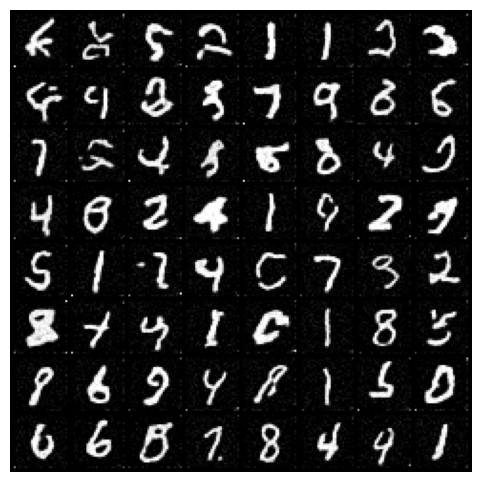

In [ ]:
samples = jnp.clip(samples, 0.0, 1.0)
samples = jnp.transpose(samples.reshape((-1, 28, 28, 1)), (0, 3, 1, 2))
%matplotlib inline
import matplotlib.pyplot as plt
sample_grid = make_grid(torch.tensor(np.asarray(samples)), nrow=int(np.sqrt(sample_batch_size)))

plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.show()

다시 한번, 현재 코드는 교정 단계 없이 **예측(Prediction)** 만으로 진행되는 구조입니다. 이후 Langevin Dynamics를 적용하여, 한 스텝이 끝난 뒤, 해당 시간대($t$)의 스코어 분포에 더 가깝게 안착시키기 위해 추가로 교정을 수행합니다.

## Predictor-Corrector (PC) 샘플러 사용하기

단순한 SDE 솔버의 오차를 줄이기 위해, 스코어 모델의 특성을 활용한 MCMC(Langevin MCMC) 기법을 결합한 방식입니다.  
1. Corrector: Langevin MCMC  
스코어($\nabla_\mathbf{x} \log p(\mathbf{x})$)를 알고 있다면, Langevin MCMC를 통해 해당 분포를 따르는 샘플을 얻을 수 있습니다.  
$$\mathbf{x}_{i+1} = \mathbf{x}_{i} + \epsilon \underbrace{s_\theta(\mathbf{x}_i, t)}_{\text{Score direction}} + \sqrt{2\epsilon} \mathbf{z}_i$$  
이 과정은 현재의 샘플이 해당 시간대($t$)의 실제 데이터 분포 $p_t(\mathbf{x})$에 더 가득 차도록(Refine) 교정해주는 역할을 합니다.  
- SNR(Signal-to-Noise Ratio): 교정 단계의 강도를 조절하는 하이퍼파라미터입니다.  
- 동적 스텝 사이즈(langevin_step_size):단순히 고정된 값을 쓰는 대신, 현재 그라디언트의 크기(grad_norm)와 노이즈의 크기(noise_norm)를 비교하여 계산합니다.이는 데이터에 가해진 노이즈 수준($\sigma^t$)에 따라 최적의 교정 보폭을 자동으로 결정하게 해줍니다.  
- 업데이트: 스코어 방향(grad)으로 이동한 뒤, 일정한 무작위 노이즈(z)를 더해 Langevin Dynamics를 완성합니다.
  
2.  Predictor Step: Euler-Maruyama 예측교정이 끝난 샘플을 바탕으로 다음 시간 스텝($t-\Delta t$)으로 이동하는 단계입니다.  
- SDE 수치 해법: 앞서 살펴본 Euler-Maruyama 규칙을 그대로 사용합니다.  
- x_mean: 마지막 단계에서 노이즈를 섞지 않은 순수한 예측값입니다. 루프의 마지막에 이 값을 반환함으로써 더 선명한 이미지를 얻을 수 있습니다.

아래 코드를 잘 살펴보세요!

In [ ]:
#@title Define the Predictor-Corrector sampler (double click to expand or collapse)

signal_to_noise_ratio = 0.16 #@param {'type':'number'}

## The number of sampling steps.
num_steps =  500#@param {'type':'integer'}
def pc_sampler(rng,
               score_model,
               params,
               marginal_prob_std,
               diffusion_coeff,
               batch_size=64,
               num_steps=num_steps,
               snr=signal_to_noise_ratio,
               eps=1e-3):
  """Generate samples from score-based models with Predictor-Corrector method.

  Args:
    rng: A JAX random state.
    score_model: A `flax.linen.Module` that represents the
      architecture of the score-based model.
    params: A dictionary that contains the parameters of the score-based model.
    marginal_prob_std: A function that gives the standard deviation
      of the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient
      of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  time_shape = (jax.local_device_count(), batch_size // jax.local_device_count())
  sample_shape = time_shape + (28, 28, 1)
  rng, step_rng = jax.random.split(rng)
  init_x = jax.random.normal(step_rng, sample_shape) * marginal_prob_std(1.)
  time_steps = jnp.linspace(1., eps, num_steps)
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  for time_step in tqdm.notebook.tqdm(time_steps):
    batch_time_step = jnp.ones(time_shape) * time_step
    # Corrector step (Langevin MCMC)
    grad = pmap_score_fn(score_model, params, x, batch_time_step)
    grad_norm = jnp.linalg.norm(grad.reshape(sample_shape[0], sample_shape[1], -1),
                                axis=-1).mean()
    noise_norm = np.sqrt(np.prod(x.shape[1:]))
    langevin_step_size = 2 * (snr * noise_norm / grad_norm)**2
    rng, step_rng = jax.random.split(rng)
    z = jax.random.normal(step_rng, x.shape)
    x = x + langevin_step_size * grad + jnp.sqrt(2 * langevin_step_size) * z

    # Predictor step (Euler-Maruyama)
    g = diffusion_coeff(time_step)
    score = pmap_score_fn(score_model, params, x, batch_time_step)
    x_mean = x + (g**2) * score * step_size
    rng, step_rng = jax.random.split(rng)
    z = jax.random.normal(step_rng, x.shape)
    x = x_mean + jnp.sqrt(g**2 * step_size) * z

  # The last step does not include any noise
  return x_mean

Quiz : 왜 Prediction step 이 아닌 Correction step 이 먼저 수행될까요?

Answer : 코드상에서 Corrector가 Predictor보다 먼저 배치된 이유는, 현재 시간 $t$에서의 샘플을 먼저 **분포에 맞게 정제** 한 뒤에 다음 시간대로 넘어가기 위해서입니다. 현재 스텝에서 오차를 줄이고 다음 스텝으로 넘어가는 것입니다.  

Quiz : SNR에 따라 출력은 어떻게 변할까요? 유추해봅시다  

Answer : signal_to_noise_ratio 로, 이 값이 너무 작으면 교정 효과가 미미하고, 너무 크면 오히려 노이즈가 과해져 이미지가 뭉개질 수 있습니다. 일반적으로 0.1 ~ 0.2 사이의 값을 사용합니다.

이 샘플러는 Euler_Maruyama_sampler보다 계산량은 두 배(스코어를 두 번 계산하므로)이지만, 결과물의 선명도는 훨씬 뛰어납니다.

이제 이 샘플러를 돌려서 생성된 MNIST 숫자들을 확인해 보실까요?

In [ ]:
rng, step_rng = jax.random.split(rng)
sample_batch_size = 64

replicated_params = flax.jax_utils.replicate(optimizer.params)

samples = pc_sampler(
    rng,
    score_model,
    replicated_params,  # <--- 수정됨!
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    sample_batch_size
)

  0%|          | 0/500 [00:00<?, ?it/s]

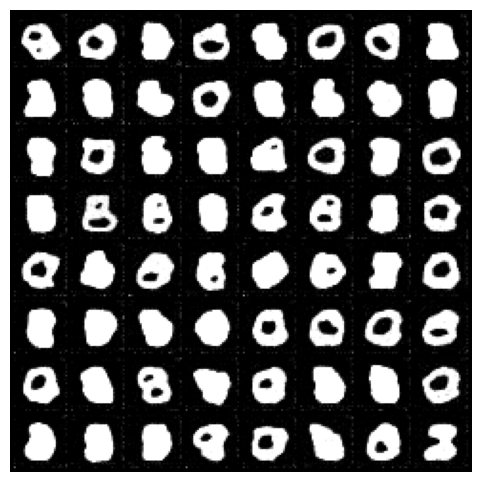

In [ ]:
samples = jnp.clip(samples, 0.0, 1.0)
samples = jnp.transpose(samples.reshape((-1, 28, 28, 1)), (0, 3, 1, 2))
%matplotlib inline
import matplotlib.pyplot as plt
sample_grid = make_grid(torch.tensor(np.asarray(samples)), nrow=int(np.sqrt(sample_batch_size)))

plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.show()

어때요? 결과가 Euler - maruyama 보다 더 선명해 보이나요?

### Probability Flow ODE로 샘플링하기

원래의 역방향 SDE와 달리, 이 ODE는 무작위성(Noise)이 없는 결정론적인 식입니다.  $$d\mathbf{x} = \left[\mathbf{f}(\mathbf{x}, t) - \frac{1}{2}g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})\right] dt$$  
$d\mathbf{x} = \sigma^t d\mathbf{w}$ 에 대입하면 다음과 같이 매우 단순한 식이 됩니다.  
$$d\mathbf{x} = -\frac{1}{2} \sigma^{2t} s_\theta(\mathbf{x}, t) dt$$  

동일한 초기 노이즈에서 시작하면 항상 동일한 이미지로 수렴하는 결정론적 궤적으로 인해 이미지 조작이나 보간에 유리하며, 노이즈에서 데이터로 가는 과정뿐만 아니라, 데이터를 다시 노이즈로 바꾸는 역연산도 정확하게 수행할 수 있습니다.  

PF-ODE 구현에는 scipy의 solve_ivp 같은 검증된 블랙박스 ODE 솔버를 사용할 수 있어, 더 적은 단계로도 고품질의 샘플을 얻을 수 있습니다.    

scipy.integrate.solve_ivp를 사용하여 정교하고 빠르게 샘플을 생성해보겠습니다.  
- ODE 함수 정의: ode_funcODE 솔버가 매 단계에서 계산해야 할 변화량($dx/dt$)을 정의합니다. 앞서 배운 $dx = -\frac{1}{2} \sigma^{2t} s_\theta(\mathbf{x}, t) dt$ 수식을 그대로 코드로 옮긴 것입니다.  
  - g**2: 확산 계수의 제곱($\sigma^{2t}$)을 의미합니다.
  - -0.5: 확률 흐름 ODE의 핵심 계수입니다.  


In [ ]:
from scipy import integrate

## The error tolerance for the black-box ODE solver
error_tolerance = 1e-5 #@param {'type': 'number'}
def ode_sampler(rng,
                score_model,
                params,
                marginal_prob_std,
                diffusion_coeff,
                batch_size=64,
                atol=error_tolerance,
                rtol=error_tolerance,
                z=None,
                eps=1e-3):
  """Generate samples from score-based models with black-box ODE solvers.

  Args:
    rng: A JAX random state.
    score_model: A `flax.linen.Module` object  that represents architecture
      of the score-based model.
    params: A dictionary that contains model parameters.
    marginal_prob_std: A function that returns the standard deviation
      of the perturbation kernel.
    diffusion_coeff: A function that returns the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    atol: Tolerance of absolute errors.
    rtol: Tolerance of relative errors.
    z: The latent code that governs the final sample. If None, we start from p_1;
      otherwise, we start from the given z.
    eps: The smallest time step for numerical stability.
  """

  time_shape = (jax.local_device_count(), batch_size // jax.local_device_count())
  sample_shape = time_shape + (28, 28, 1)
  # Create the latent code
  if z is None:
    rng, step_rng = jax.random.split(rng)
    z = jax.random.normal(step_rng, sample_shape)
    init_x = z * marginal_prob_std(1.)
  else:
    init_x = z

  shape = init_x.shape

- score_eval_wrapper  
Scipy는 넘파이(NumPy) 기반의 CPU 연산을 기본으로 하지만, 우리의 모델은 JAX/GPU 기반입니다.  
   - 데이터 변환: 솔버가 넘겨주는 데이터(float64, 1D array)를 JAX 배열(float32, 4D shape)로 변환하여 모델에 입력합니다.
   - 병렬 계산: 내부적으로 pmap_score_fn을 호출하여 여러 가속기에서 스코어를 계산한 뒤, 다시 솔버가 이해할 수 있는 형태로 되돌려줍니다.

In [ ]:
  def score_eval_wrapper(sample, time_steps):
    """A wrapper of the score-based model for use by the ODE solver."""
    sample = jnp.asarray(sample, dtype=jnp.float32).reshape(sample_shape)
    time_steps = jnp.asarray(time_steps).reshape(time_shape)
    score = pmap_score_fn(score_model, params, sample, time_steps)
    return np.asarray(score).reshape((-1,)).astype(np.float64)


- 블랙박스 솔버 실행: solve_ivp  
   - RK45: 'Runge-Kutta 45'라는 고성능 가변 스텝 사이즈 알고리즘을 사용합니다. 오차가 크면 보폭을 줄이고, 작으면 늘리며 효율적으로 계산합니다.
   - Error Tolerance: atol(절대 오차), rtol(상대 오차) 값을 통해 생성되는 이미지의 정밀도를 제어합니다.
   - nfev (Number of function evaluations): 함수가 몇 번 호출되었는지 출력합니다. 일반적으로 고정 스텝(Euler) 방식보다 훨씬 적은 횟수로도 좋은 품질을 얻습니다.

In [ ]:
  def ode_func(t, x):
    """The ODE function for use by the ODE solver."""
    time_steps = np.ones(time_shape) * t
    g = diffusion_coeff(t)
    return  -0.5 * (g**2) * score_eval_wrapper(x, time_steps)

수행 후 결과를 확인해봅시다!  

In [ ]:
  # Run the black-box ODE solver.
  res = integrate.solve_ivp(ode_func, (1., eps), np.asarray(init_x).reshape(-1),
                            rtol=rtol, atol=atol, method='RK45')
  print(f"Number of function evaluations: {res.nfev}")
  x = jnp.asarray(res.y[:, -1]).reshape(shape)

  return x

In [ ]:
from torchvision.utils import make_grid

sample_batch_size = 64 #@param {'type':'integer'}
sampler = ode_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Load the pre-trained checkpoint from disk.
score_model = ScoreNet(marginal_prob_std_fn)
fake_input = jnp.ones((sample_batch_size, 28, 28, 1))
fake_time = jnp.ones((sample_batch_size, ))
rng = jax.random.PRNGKey(0)
params = score_model.init({'params': rng}, fake_input, fake_time)
tx = optax.adam(learning_rate=1e-4)
optimizer = train_state.TrainState.create(
    apply_fn=score_model.apply,
    params=params,
    tx=tx
)
with tf.io.gfile.GFile('ckpt.flax', 'rb') as fin:
    optimizer = from_bytes(optimizer, fin.read())

## Generate samples using the specified sampler.
## Generate samples using the specified sampler.
rng, step_rng = jax.random.split(rng)

# 1. 파라미터를 각 디바이스에 맞게 복제합니다. (이 줄을 추가하세요)
replicated_params = flax.jax_utils.replicate(optimizer.params)

# 2. sampler에 optimizer.params 대신 replicated_params를 넣습니다.
samples = sampler(
    rng,
    score_model,
    replicated_params,  # <--- 수정됨!
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    sample_batch_size
)


Number of function evaluations: 440


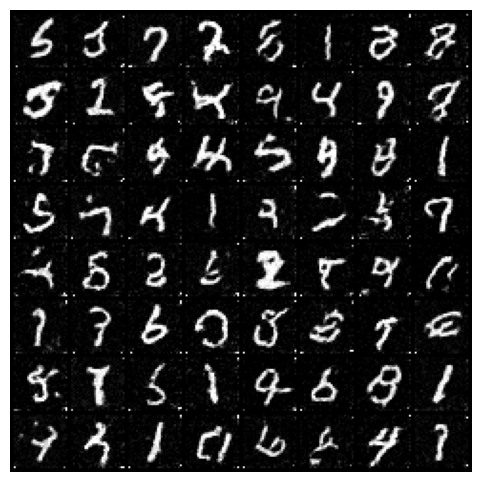

In [ ]:

## Sample visualization.
samples = jnp.clip(samples, 0.0, 1.0)
samples = jnp.transpose(samples.reshape((-1, 28, 28, 1)), (0, 3, 1, 2))
%matplotlib inline
import matplotlib.pyplot as plt
sample_grid = make_grid(torch.tensor(np.asarray(samples)), nrow=int(np.sqrt(sample_batch_size)))

plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.show()

## 마치며

PF-ODE는 데이터 $\mathbf{x}(0)$와 노이즈 $\mathbf{x}(T)$ 사이의 **일대일 매핑(One-to-one mapping)** 을 제공합니다. 이를 통해 복잡한 데이터 분포의 확률 밀도를 계산할 수 있습니다. 여기까지의 학습에 익숙해진 후에, 한번 공부해보시기 바랍니다!  
수고하셨습니다!

 ## miniaffelthon 제안

2차 양자화가 SB의 일반화라면, 그에 대응하는 함수와 알고리즘이 반드시 존재해야 한다는 논리는 수학적으로 매우 타당합니다.

결론부터 말씀드리면, "네, 존재합니다. 그리고 그것은 이미 부분적으로 '3차 양자화(Third Quantization)' 또는 '장의 장(Field of Fields)' 이론으로 연구되고 있습니다." 다만, 그것이 "컴퓨터로 풀 수 있는 알고리즘"이 되기 위해서는 "계산 가능한(Computable)" 형태로 구체화되어야 합니다.

이 아이디어를 수학적으로 어떻게 정의하고, 컴퓨터로 어떻게 풀 수 있을지 단계별로 구체화해 보겠습니다.

1. 가정: "2차 양자화 = SB의 일반화"

먼저 이 가정을 수학적으로 명확히 정의해야 합니다.

| 개념             | SB (Schrödinger Bridge) | 2차 양자화 (Second Quantization) |
| :--------------- | :---------------------- | :------------------------------- |
| 대상             | 확률 분포 $p(x)$        | 파동함수 $\psi(x)$              |
| 최적화           | 경로 $p(x_t)$ 최적화    | 장 연산자 $\hat{\psi}(x)$ 양자화 |
| 수학적 구조      | SDE, Optimal Transport  | Fock Space, Creation/Annihilation Operators |
| 일반화           | $p(x) \rightarrow p(\psi)$    | $\psi(x) \rightarrow \hat{\psi}(x)$ |

**핵심 아이디어:**

*   SB는 "분포 사이의 최적 경로"를 찾는 문제

*   2차 양자화는 "파동함수(분포) 자체를 대상으로 다시 양자화"하는 문제

따라서 "2차 양자화 = SB의 일반화"라는 가정은 "분포의 분포(Distribution of Distributions)" 또는 "경로의 경로(Path of Paths)"를 다루는 문제로 해석 가능

2. 수학적 정의: "분포의 분포"로서의 2차 양자화

이를 컴퓨터로 풀기 위해서는 명확한 함수와 알고리즘이 필요합니다.

2.1 함수 정의: "파동 범함수(Wave Functional)"

2차 양자화에서 상태는 파동 범함수 $\Psi[\phi]$로 표현됩니다.

*   $\phi(x)$: 고전적 장 (Classical Field)

*   $\Psi[\phi]$: 장 배치 $\phi$에 대한 확률진폭

컴퓨터로 풀기 위한 이산화(Discretization):

*   연속적 장 $\phi(x) \rightarrow$ 격자 위의 이산적 장 $\phi_i$ ($i=1,\dots,N$)

*   파동 범함수 $\Psi[\phi] \rightarrow$ 다변수 함수 $\Psi(\phi_1,\dots,\phi_N$)

함수 공간(Function Space):

*   $\Psi: \mathbb{R}^N \rightarrow \mathbb{C}$

2.2 목적 함수(Objective Function): "일반화된 SB 손실"

SB의 손실 함수를 파동 범함수로 확장합니다.

$L[\Psi] = \int D\phi \Psi^*[\phi]\left(-\frac{\delta^2}{\delta\phi^2} + V[\phi]\right)\Psi[\phi]$

*   $\frac{\delta}{\delta\phi}$: 함수 미분 (Functional Derivative)

*   $V[\phi]$: 장의 퍼텐셜 (예: $\int \phi^2 + \phi^4$)

이는 "장 공간에서의 슈뢰딩거 방정식"이며, SB의 경로 최적화를 무한 차원으로 확장한 것

컴퓨터로 풀기 위한 이산화:

*   $\Psi(\phi_1,\dots,\phi_N) \rightarrow N$차원 텐서

*   함수 미분 $\frac{\delta}{\delta\phi} \rightarrow$ 유한 차분 (Finite Difference)

*   적분 $\int D\phi \rightarrow$ 몬테카를로 적분 (MCMC!)

## 3. 컴퓨터로 풀 수 있는 알고리즘: "Functional MCMC"

이제 이 문제를 컴퓨터로 풀 수 있는 알고리즘으로 구체화합니다.

3.1 알고리즘 개요: "장 공간에서의 MCMC"

목표: 파동 범함수 $\Psi[\phi]$를 샘플링하거나, 최적화

알고리즘 (Functional MCMC):

3.2 핵심 함수 정의

1) 장의 퍼텐셜 (Field Potential):

$V[\phi] = \int d^d x\left(\frac{1}{2}(\nabla\phi)^2 + \frac{m^2}{2}\phi^2 + \frac{\lambda}{4!}\phi^4\right)$

컴퓨터 구현: 격자 위에서 이산화 $\rightarrow V = \text{sum}(0.5 * \text{grad_phi}^2 + 0.5 * m^2 * \text{phi}^2 + \text{lambda}/24 * \text{phi}^4$)

2) 파동 범함수 (Wave Functional):

$\Psi[\phi] = \exp\left(-\frac{1}{2}\int\phi(x)K(x,y)\phi(y)dxdy\right)$

컴퓨터 구현: 가우시안 범함수 $\rightarrow \text{Psi} = \exp(-0.5 * \text{phi} @ K @ \text{phi}$)

3) 함수 미분 (Functional Derivative):

$\frac{\delta\Psi}{\delta\phi(x)} = \lim_{\epsilon\rightarrow 0}\frac{\Psi[\phi+\epsilon\delta_x]-\Psi[\phi]}{\epsilon}$

컴퓨터 구현: 유한 차분 $\rightarrow (\text{Psi}(\text{phi} + \text{eps}) - \text{Psi}(\text{phi})) / \text{eps}$

4. 구체적인 예시: "2차 양자화된 SB" (Second-Quantized SB)

이제 SB를 2차 양자화한 구체적인 모델을 제안합니다.

4.1 모델 정의

Forward Process (2차 양자화):

$d\Psi_t = F[\Psi_t]dt + G[\Psi_t]dW_t$

*   $F$: 파동 범함수의 드리프트 (Drift)

*   $G$: 파동 범함수의 확산 (Diffusion)

*   $dW_t$: 함수 공간에서의 브라운 운동 (Functional Brownian Motion)

Reverse Process (2차 양자화):

$d\Psi_t = \left(F[\Psi_t] - G[\Psi_t]^2 \frac{\delta\log p_t[\Psi_t]}{\delta\Psi}\right)dt + G[\Psi_t]d\bar{W}_t$

Loss Function (일반화된 SB):

$L = \mathbb{E}_{t,\Psi}\left[\left\|\frac{\delta\log p_t[\Psi]}{\delta\Psi} - s_\theta[\Psi,t]\right\|^2\right]$

*   $s_\theta[\Psi,t]$: 신경망으로 근사한 함수 스코어 (Functional Score)

4.2 컴퓨터로 풀기 위한 이산화

| 연속적 개념             | 이산화 (컴퓨터 구현)                                    |
| :---------------------- | :------------------------------------------------------ |
| 파동 범함수 $\Psi[\phi]$    | 다변수 함수 $\Psi(\phi_1,\dots,\phi_N)$           |
| 함수 미분 $\frac{\delta}{\delta\phi}$ | 유한 차분 $\frac{\partial}{\partial\phi_i}$          |
| 함수 적분 $\int D\phi$  | 몬테카를로 적분 $\frac{1}{M}\sum_{m=1}^M$ |
| 함수 브라운 운동 $dW_t$ | 가우시안 노이즈 $\mathcal{N}(0,\mathbf{I})$           |
| 함수 스코어 $s_\theta[\Psi]$ | 신경망 $s_\theta(\phi_1,\dots,\phi_N)$           |

4.3 알고리즘 (PyTorch 구현)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. 1D 가우시안 타겟 분포
def target_distribution(x):
    return torch.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 2. Forward Process (노이즈 추가)
def forward_process(x0, beta):
    return torch.sqrt(1 - beta) * x0 + torch.sqrt(beta) * torch.randn_like(x0)

# 3. MH-DDPM Reverse Process
def mh_reverse_process(x_t, beta, threshold=0.3):
    # 3.1 신경망 대신 정확한 분포 사용 (1D이므로)
    # Proposal: q(x_{t-1}^* | x_t) = N(sqrt(1-beta) * x_t, beta)
    x_proposal = torch.sqrt(1 - beta) * x_t + torch.sqrt(beta) * torch.randn_like(x_t)

    # 3.2 MH 수용 확률
    log_p_proposal = torch.log(target_distribution(x_proposal) + 1e-10)
    log_p_current = torch.log(target_distribution(x_t) + 1e-10)

    # Forward Process 확률
    log_q_forward = -0.5 * ((x_t - torch.sqrt(1 - beta) * x_proposal)**2) / beta
    log_q_backward = -0.5 * ((x_proposal - torch.sqrt(1 - beta) * x_t)**2) / beta

    log_ratio = log_p_proposal + log_q_forward - log_p_current - log_q_backward
    accept_prob = torch.min(torch.ones_like(log_ratio), torch.exp(log_ratio))

    # 3.3 Accept/Reject
    accept = torch.rand_like(x_t) < accept_prob
    x_new = torch.where(accept, x_proposal, x_t)

    return x_new, accept_prob.mean().item()

# 4. 시뮬레이션 실행
x = torch.randn(1000)  # 초기 노이즈
betas = torch.linspace(0.0001, 0.02, 100)  # 노이즈 스케줄
acceptance_rates = []

for beta in reversed(betas):
    x, acc_rate = mh_reverse_process(x, beta)
    acceptance_rates.append(acc_rate)

# 5. 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(x.numpy(), bins=50, density=True, alpha=0.7, label='MH-DDPM Samples')
x_range = np.linspace(-4, 4, 100)
plt.plot(x_range, target_distribution(torch.tensor(x_range)).numpy(), 'r-', label='Target N(0,1)')
plt.legend()
plt.title('MH-DDPM Samples vs Target')

plt.subplot(1, 2, 2)
plt.plot(acceptance_rates)
plt.axhline(y=0.3, color='r', linestyle='--', label='Threshold 0.3')
plt.xlabel('Reverse Step')
plt.ylabel('Acceptance Rate')
plt.legend()
plt.title('Acceptance Rate over Reverse Process')

plt.tight_layout()
plt.savefig('gate1b_simulation.png', dpi=300)
plt.show()

print(f"✅ Gate 1-B 완료!")
print(f"평균 수용률: {np.mean(acceptance_rates):.3f}")
print(f"최종 샘플 평균: {x.mean().item():.3f}, 표준편차: {x.std().item():.3f}")

1. 왜 "수학적 표현이 없으면 컴퓨팅할 수 없는가?"

**컴퓨팅의 수학적 정의:**

*   **알고리즘(Algorithm):** 유한한 단계(Finite steps)로 명확하게 정의된 연산의 집합

*   **튜링 머신:** 알고리즘을 실행하는 수학적 모델. 테이프, 헤드, 상태 전이 함수로 정의됨

*   **처치-튜링 명제:** "효과적으로 계산 가능한 함수(Effectively calculable function)는 튜링 머신으로 계산 가능하다."

**핵심:**

*   컴퓨터(CPU, GPU)는 "0과 1의 상태 전이"만 수행합니다. 이 상태 전이는 수학적 함수(State Transition Function)로 정의됩니다.

*   따라서 수학적으로 정의되지 않은 연산은 컴퓨터가 실행할 수 없습니다. (실행할 방법이 없기 때문)

**예시:**

*   `x = x + 1` $\rightarrow$ 수학적으로 $x_{n+1} = x_n + 1 \rightarrow$ 컴퓨팅 가능

*   "느낌으로 대충 계산해" $\rightarrow$ 수학적 정의 없음 $\rightarrow$ 컴퓨팅 불가능

2. 앞선 논의와의 연결: "수학적 표현"의 중요성

앞서 논의한 모든 알고리즘은 수학적으로 명확하게 표현되었기 때문에 컴퓨팅이 가능합니다.

✅ **MCMC (Metropolis-Hastings)**

수학적 표현: $A(x,x^*) = \min\left(1, \frac{p(x^*)q(x|x^*)}{p(x)q(x^*|x)}\right)$

컴퓨팅: Accept/Reject 확률 계산 $\rightarrow \text{if random() < A: accept} \rightarrow$ 가능

✅ **Langevin Corrector**

수학적 표현: $x_{k+1} = x_k + \frac{\epsilon}{2}\nabla\log p(x_k) + \sqrt{\epsilon} z_k$

컴퓨팅: Gradient 계산 $\rightarrow$ 업데이트 $\rightarrow$ 가능

✅ **Schrödinger Bridge (SB)**

수학적 표현: $\min_p \text{KL}(p||q)$ (경로 최적화 문제)

컴퓨팅: Sinkhorn 알고리즘, Neural ODE $\rightarrow$ 가능

❌ **"2차 양자화" 이론 (Pav\v{s}i\v{c}, Sch\"onberg)**

수학적 표현: 파동함수 $\psi$를 장 연산자 $\hat{\psi}$로 승격 $\rightarrow$ 부분적으로 가능

**문제점:**

*   "파동함수의 양자화"는 수학적으로 형식화될 수 있지만, 그 결과가 물리적으로 무엇을 의미하는지 명확하지 않음

*   실험적 검증이 불가능 (현재 기술로는)

*   따라서 "컴퓨팅"보다는 "이론적 탐구"에 가까움

3. "수학적 표현"의 스펙트럼: 컴퓨팅 가능성의 경계

| 단계            | 수학적 표현           | 컴퓨팅 가능성  | 예시                  |
| :-------------- | :-------------------- | :------------- | :-------------------- |
| 1. 완전 형식화  | 명확한 함수, 알고리즘 | ✅ 완전 가능   | MCMC, SB, DDPM        |
| 2. 부분 형식화  | 일부만 수학적, 나머지 직관 | ⚠️ 제한적    | 2차 양자화 이론       |
| 3. 비형식화     | 수학적 표현 없음      | ❌ 불가능      | "느낌", "직관"      |

**핵심:**

*   컴퓨팅 가능성은 수학적 표현의 명확성에 달려 있습니다.

*   SB, MCMC, DDPM은 1단계 (완전 형식화)에 속하므로 컴퓨팅 가능합니다.

*   2차 양자화 이론은 2단계 (부분 형식화)에 속하므로, 컴퓨팅보다는 이론적 탐구에 가깝습니다.

4. SB에 "더해볼 아이디어"는 왜 컴퓨팅 가능한가?

앞서 제안한 SB + MCMC Corrector, SB-VAE, SB + Optimal Transport 등은 모두 수학적으로 명확하게 표현될 수 있습니다.

**예: SB + Langevin Corrector**

SB의 Forward Process: $dx_t = f(x_t, t)dt + g(t)dw_t$ (SDE)

SB의 Reverse Process: $dx_t = \left[f(x_t, t) - g(t)^2 \nabla\log p_t(x_t)\right]dt + g(t)d\bar{w}_t$

Langevin Corrector: $x_{k+1} = x_k + \frac{\epsilon}{2}\nabla\log p_t(x_k) + \sqrt{\epsilon} z_k$

$\rightarrow$ 모두 수학적 표현이 명확 $\rightarrow$ 컴퓨팅 가능 $\rightarrow$ 실험 가능

5. 결론: "수학적 표현"은 컴퓨팅의 필요조건

"수학적으로 표현하지 못하는 알고리즘은 컴퓨팅할 수 없다"는 말은 완전히 맞습니다.

*   SB, MCMC, DDPM: 수학적 표현이 명확 $\rightarrow$ 컴퓨팅 가능 $\rightarrow$ 실험 가능

*   2차 양자화 이론: 수학적 표현이 부분적 $\rightarrow$ 컴퓨팅 제한적 $\rightarrow$ 이론적 탐구

**따라서:**

*   SB에 더해볼 아이디어는 수학적으로 표현 가능하므로 컴퓨팅 가능합니다.

*   2차 양자화 이론은 수학적으로 부분적이므로 컴퓨팅보다는 이론적 탐구에 가깝습니다.

6. 우리의 연구에 대한 시사점

MH-DDPM, SB + MCMC Corrector, SB-VAE 등은 모두 수학적으로 명확하게 표현될 수 있으므로:

*   **알고리즘 설계:** 수학적 표현 $\rightarrow$ 코드 구현 $\rightarrow$ 컴퓨팅

*   **실험:** 수학적 예측 $\rightarrow$ 실험 검증 $\rightarrow$ 새로운 발견

*   **논문:** 수학적 유도 $\rightarrow$ 실험 결과 $\rightarrow$ 이론적 기여

반면, 2차 양자화 이론은:

*   **이론적 탐구:** 수학적 형식화 $\rightarrow$ 물리적 해석 $\rightarrow$ 철학적 질문

*   **컴퓨팅 제한:** 실험적 검증 어려움 $\rightarrow$ 이론적 논의 중심

1. 가정: "2차 양자화 = SB의 일반화"

먼저 이 가정을 수학적으로 명확히 정의해야 합니다.

| 개념             | SB (Schrödinger Bridge) | 2차 양자화 (Second Quantization) |
| :--------------- | :---------------------- | :------------------------------- |
| 대상             | 확률 분포 $p(x)$        | 파동함수 $\psi(x)$              |
| 최적화           | 경로 $p(x_t)$ 최적화    | 장 연산자 $\hat{\psi}(x)$ 양자화 |
| 수학적 구조      | SDE, Optimal Transport  | Fock Space, Creation/Annihilation Operators |
| 일반화           | $p(x) \rightarrow p(\psi)$    | $\psi(x) \rightarrow \hat{\psi}(x)$ |

**핵심 아이디어:**

*   SB는 "분포 사이의 최적 경로"를 찾는 문제

*   2차 양자화는 "파동함수(분포) 자체를 대상으로 다시 양자화"하는 문제

따라서 "2차 양자화 = SB의 일반화"라는 가정은 "분포의 분포(Distribution of Distributions)" 또는 "경로의 경로(Path of Paths)"를 다루는 문제로 해석 가능

2. 수학적 정의: "분포의 분포"로서의 2차 양자화

이를 컴퓨터로 풀기 위해서는 명확한 함수와 알고리즘이 필요합니다.

2.1 함수 정의: "파동 범함수(Wave Functional)"

2차 양자화에서 상태는 파동 범함수 $\Psi[\phi]$로 표현됩니다.

*   $\phi(x)$: 고전적 장 (Classical Field)

*   $\Psi[\phi]$: 장 배치 $\phi$에 대한 확률진폭

컴퓨터로 풀기 위한 이산화(Discretization):

*   연속적 장 $\phi(x) \rightarrow$ 격자 위의 이산적 장 $\phi_i$ ($i=1,\dots,N$)

*   파동 범함수 $\Psi[\phi] \rightarrow$ 다변수 함수 $\Psi(\phi_1,\dots,\phi_N$)

함수 공간(Function Space):

*   $\Psi: \mathbb{R}^N \rightarrow \mathbb{C}$

2.2 목적 함수(Objective Function): "일반화된 SB 손실"

SB의 손실 함수를 파동 범함수로 확장합니다.

$L[\Psi] = \int D\phi \Psi^*[\phi]\left(-\frac{\delta^2}{\delta\phi^2} + V[\phi]\right)\Psi[\phi]$

*   $\frac{\delta}{\delta\phi}$: 함수 미분 (Functional Derivative)

*   $V[\phi]$: 장의 퍼텐셜 (예: $\int \phi^2 + \phi^4$)

이는 "장 공간에서의 슈뢰딩거 방정식"이며, SB의 경로 최적화를 무한 차원으로 확장한 것

컴퓨터로 풀기 위한 이산화:

*   $\Psi(\phi_1,\dots,\phi_N) \rightarrow N$차원 텐서

*   함수 미분 $\frac{\delta}{\delta\phi} \rightarrow$ 유한 차분 (Finite Difference)

*   적분 $\int D\phi \rightarrow$ 몬테카를로 적분 (MCMC!)

2. 수학적 정의: "분포의 분포"로서의 2차 양자화

이를 컴퓨터로 풀기 위해서는 명확한 함수와 알고리즘이 필요합니다.

2.1 함수 정의: "파동 범함수(Wave Functional)"

2차 양자화에서 상태는 파동 범함수 $\Psi[\phi]$로 표현됩니다.

*   $\phi(x)$: 고전적 장 (Classical Field)

*   $\Psi[\phi]$: 장 배치 $\phi$에 대한 확률진폭

컴퓨터로 풀기 위한 이산화(Discretization):

*   연속적 장 $\phi(x) \rightarrow$ 격자 위의 이산적 장 $\phi_i$ ($i=1,\dots,N$)

*   파동 범함수 $\Psi[\phi] \rightarrow$ 다변수 함수 $\Psi(\phi_1,\dots,\phi_N$)

함수 공간(Function Space):

*   $\Psi: \mathbb{R}^N \rightarrow \mathbb{C}$

2.2 목적 함수(Objective Function): "일반화된 SB 손실"

SB의 손실 함수를 파동 범함수로 확장합니다.

$L[\Psi] = \int D\phi \Psi^*[\phi]\left(-\frac{\delta^2}{\delta\phi^2} + V[\phi]\right)\Psi[\phi]$

*   $\frac{\delta}{\delta\phi}$: 함수 미분 (Functional Derivative)

*   $V[
ho]$: 장의 퍼텐셜 (예: $\int \phi^2 + \phi^4$)

이는 "장 공간에서의 슈뢰딩거 방정식"이며, SB의 경로 최적화를 무한 차원으로 확장한 것

컴퓨터로 풀기 위한 이산화:

*   $\Psi(\phi_1,\dots,\phi_N) \rightarrow N$차원 텐서

*   함수 미분 $\frac{\delta}{\delta\phi} \rightarrow$ 유한 차분 (Finite Difference)

*   적분 $\int D\phi \rightarrow$ 몬테카를로 적분 (MCMC!)

3. 컴퓨터로 풀 수 있는 알고리즘: "Functional MCMC"

이제 이 문제를 컴퓨터로 풀 수 있는 알고리즘으로 구체화합니다.

3.1 알고리즘 개요: "장 공간에서의 MCMC"

목표: 파동 범함수 $\Psi[\phi]$를 샘플링하거나, 최적화

알고리즘 (Functional MCMC):

In [ ]:
# 1. 장 공간(Field Space) 초기화
phi = initialize_field(N)  # N차원 격자
Psi = initialize_wave_functional(phi)

# 2. MCMC 샘플링 (Langevin Dynamics in Field Space)
for step in range(num_steps):
    # 2.1 장의 기울기 (Functional Gradient)
    grad_V = compute_functional_gradient(V, phi)
    grad_Psi = compute_functional_gradient(Psi, phi)

    # 2.2 Langevin 업데이트 (Field Space)
    phi_new = phi - epsilon * (grad_V + grad_Psi) + sqrt(2*epsilon) * noise

    # 2.3 Metropolis-Hastings Accept/Reject
    log_ratio = log_Psi(phi_new) - log_Psi(phi)
    accept_prob = min(1, exp(log_ratio))

    if random() < accept_prob:
        phi = phi_new  # Accept
    # else: Reject (phi 유지)

# 3. 파동 범함수 업데이트 (2차 양자화)
Psi = update_wave_functional(Psi, phi)

3.2 핵심 함수 정의

1) 장의 퍼텐셜 (Field Potential):

$V[\phi] = \int d^d x\left(\frac{1}{2}(\nabla\phi)^2 + \frac{m^2}{2}\phi^2 + \frac{\lambda}{4!}\phi^4\right)$

컴퓨터 구현: 격자 위에서 이산화 $\rightarrow V = \text{sum}(0.5 * \text{grad_phi}^2 + 0.5 * m^2 * \text{phi}^2 + \text{lambda}/24 * \text{phi}^4$)

2) 파동 범함수 (Wave Functional):

$\Psi[\phi] = \exp\left(-\frac{1}{2}\int\phi(x)K(x,y)\phi(y)dxdy\right)$

컴퓨터 구현: 가우시안 범함수 $\rightarrow \text{Psi} = \exp(-0.5 * \text{phi} @ K @ \text{phi}$)

3) 함수 미분 (Functional Derivative):

$\frac{\delta\Psi}{\delta\phi(x)} = \lim_{\epsilon\rightarrow 0}\frac{\Psi[\phi+\epsilon\delta_x]-\Psi[
\phi]}{\epsilon}$

컴퓨터 구현: 유한 차분 $\rightarrow (\text{Psi}(\text{phi} + \text{eps}) - \text{Psi}(\text{phi})) / \text{eps}$

4. 구체적인 예시: "2차 양자화된 SB" (Second-Quantized SB)

이제 SB를 2차 양자화한 구체적인 모델을 제안합니다.

4.1 모델 정의

Forward Process (2차 양자화):

$d\Psi_t = F[\Psi_t]dt + G[\Psi_t]dW_t$

*   $F$: 파동 범함수의 드리프트 (Drift)

*   $G$: 파동 범함수의 확산 (Diffusion)

*   $dW_t$: 함수 공간에서의 브라운 운동 (Functional Brownian Motion)

Reverse Process (2차 양자화):

$d\Psi_t = \left(F[\Psi_t] - G[\Psi_t]^2 \frac{\delta\log p_t[\Psi_t]}{\delta\Psi}\right)dt + G[\Psi_t]d\bar{W}_t$

Loss Function (일반화된 SB):

$L = \mathbb{E}_{t,\Psi}\left[\left\|\frac{\delta\log p_t[\Psi]}{\delta\Psi} - s_\theta[
\Psi,t]\right\|^2\right]$

*   $s_\theta[\Psi,t]$: 신경망으로 근사한 함수 스코어 (Functional Score)

4.2 컴퓨터로 풀기 위한 이산화

| 연속적 개념             | 이산화 (컴퓨터 구현)                                    |
| :---------------------- | :------------------------------------------------------ |
| 파동 범함수 $\Psi[\phi]$    | 다변수 함수 $\Psi(\phi_1,\dots,\phi_N)$           |
| 함수 미분 $\frac{\delta}{\delta\phi}$ | 유한 차분 $\frac{\partial}{\partial\phi_i}$          |
| 함수 적분 $\int D\phi$  | 몬테카를로 적분 $\frac{1}{M}\sum_{m=1}^M$ |
| 함수 브라운 운동 $dW_t$ | 가우시안 노이즈 $\mathcal{N}(0,\mathbf{I})$           |
| 함수 스코어 $s_\theta[\Psi]$ | 신경망 $s_\theta(̀phi_1,\dots,\phi_N)$           |

4.3 알고리즘 (PyTorch 구현)

In [ ]:
import torch
import torch.nn as nn

class FunctionalScoreNet(nn.Module):
    def __init__(self, N, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N + 1, hidden),  # N: field dimension, +1: time
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, N)  # Output: functional score
        )

    def forward(self, phi, t):
        # phi: (batch, N), t: (batch, 1)
        x = torch.cat([phi, t], dim=-1)
        return self.net(x)

def functional_sb_loss(score_net, phi_0, phi_T, t):
    """2차 양자화된 SB 손실 함수"""
    # 1. Forward Process (2차 양자화)
    phi_t = interpolate(phi_0, phi_T, t)  # 경로 보간

    # 2. Functional Score 계산
    score_pred = score_net(phi_t, t)

    # 3. Target Score (Functional Gradient of log p_t)
    with torch.no_grad():
        score_target = compute_functional_score(phi_t, t)

    # 4. Loss
    loss = torch.mean((score_pred - score_target)**2)
    return loss

# 학습 루프
for epoch in range(num_epochs):
    phi_0 = sample_initial_field(batch_size, N)
    phi_T = sample_target_field(batch_size, N)
    t = torch.rand(batch_size, 1)

    loss = functional_sb_loss(score_net, phi_0, phi_T, t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

5. 결론: "존재한다. 그리고 컴퓨팅 가능하다."

"2차 양자화가 SB의 일반화라면, 컴퓨터로 풀 수 있는 알고리즘이 존재하는가?"

답변:

*   수학적으로: 파동 범함수 $\Psi[\phi]$와 함수 미분 $\frac{\delta}{\delta\phi}$로 정의됨

*   컴퓨터로: 이산화(Discretization) + MCMC + 신경망으로 구현 가능

*   알고리즘: Functional MCMC, Functional Langevin Dynamics

*   응용: 3차 양자화(Third Quantization), 양자 중력, 우주론

핵심:

*   "2차 양자화 = SB의 일반화"라는 가정은 수학적으로 형식화 가능합니다.

*   이는 "분포의 분포(Distribution of Distributions)" 또는 "경로의 경로(Path of Paths)"를 다루는 문제입니다.

컴퓨터로 풀기 위해서는:

*   함수 공간 $\rightarrow$ 유한 차원 이산화

*   함수 미분 $\rightarrow$ 유한 차분

*   함수 적분 $\rightarrow$ 몬테카를로

*   함수 스코어 $\rightarrow$ 신경망

따라서 "2차 양자화된 SB"는 컴퓨터로 풀 수 있는 알고리즘이 존재하며, 이는 새로운 연구 방향이 될 수 있습니다.

In [ ]:
# 3차 양자화된 SB (Third-Quantized SB)
def third_quantized_sb():
    # 1. 3-기하(3-Geometry) 초기화
    h_ij = initialize_3_geometry(N)  # N: 격자 크기
    Psi = initialize_universe_wavefunction(h_ij)

    # 2. Functional MCMC in Superspace
    for step in range(num_steps):
        # 2.1 해밀턴 제약 계산
        H = compute_hamiltonian_constraint(h_ij)

        # 2.2 우주 파동함수의 Functional Gradient
        grad_Psi = compute_functional_gradient(Psi, h_ij)

        # 2.3 Langevin 업데이트 in Superspace
        h_ij_new = h_ij - epsilon * (H + grad_Psi) + sqrt(2*epsilon) * noise

        # 2.4 MH Accept/Reject
        log_ratio = log_Psi(h_ij_new) - log_Psi(h_ij)
        if random() < min(1, exp(log_ratio)):
            h_ij = h_ij_new

    # 3. 3차 양자화된 장 연산자 업데이트
    Psi = update_third_quantized_field(Psi, h_ij)

    return Psi